In [12]:
!pip install -q transformers accelerate datasets scikit-learn peft bitsandbytes
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
import pandas as pd

data = {
    "Headline": [
        "Dhaka air quality worsens",
        "Rain improves Chennai air quality",
        "Factories closed to reduce smog",
        "Air quality hazardous in Delhi",
        "Tree plantation improves local air"
    ],
    "Content": [
        "Pollution levels reach dangerous levels.",
        "After heavy rain, AQI improved significantly.",
        "Government ordered closure of polluting factories.",
        "Citizens warned to stay indoors due to high AQI.",
        "Green initiative reduced AQI levels in city."
    ],
    "Sentiment": ["Negative", "Positive", "Negative", "Negative", "Positive"]
}

df = pd.DataFrame(data)
print(df)

                             Headline  \
0           Dhaka air quality worsens   
1   Rain improves Chennai air quality   
2     Factories closed to reduce smog   
3      Air quality hazardous in Delhi   
4  Tree plantation improves local air   

                                             Content Sentiment  
0           Pollution levels reach dangerous levels.  Negative  
1      After heavy rain, AQI improved significantly.  Positive  
2  Government ordered closure of polluting factor...  Negative  
3   Citizens warned to stay indoors due to high AQI.  Negative  
4       Green initiative reduced AQI levels in city.  Positive  


In [3]:
from datasets import Dataset
from sklearn.model_selection import train_test_split

df["text"] = df["Headline"] + " " + df["Content"]
df["label"] = df["Sentiment"]

train, test = train_test_split(df, test_size=0.4, random_state=42)

def generate_prompt(row):
    return f"""
Classify air quality news as Positive or Negative.
Headline: {row['Headline']}
Content: {row['Content']}
Sentiment: {row['label']}
""".strip()

def generate_test_prompt(row):
    return f"""
Classify air quality news as Positive or Negative.
Headline: {row['Headline']}
Content: {row['Content']}
Sentiment:
""".strip()

train["text"] = train.apply(generate_prompt, axis=1)

y_true = test["label"].tolist()
X_test = pd.DataFrame(test.apply(generate_test_prompt, axis=1), columns=["text"])

train_data = Dataset.from_pandas(train[["text"]])


In [4]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

base_model_name = "microsoft/Phi-3.5-mini-instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=False,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)

model = AutoModelForCausalLM.from_pretrained(
    base_model_name,
    device_map="auto",
    quantization_config=bnb_config,
    torch_dtype=torch.float16
)

tokenizer = AutoTokenizer.from_pretrained(base_model_name)
tokenizer.pad_token_id = tokenizer.eos_token_id


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

In [6]:
def find_all_linear_names(model):
    cls = torch.nn.Linear
    lora_module_names = set()
    for name, module in model.named_modules():
        if isinstance(module, cls):
            names = name.split('.')
            lora_module_names.add(names[-1])
    if "lm_head" in lora_module_names:
        lora_module_names.remove("lm_head")
    return list(lora_module_names)

target_modules = find_all_linear_names(model)
print("✅ Target modules for LoRA:", target_modules)



✅ Target modules for LoRA: ['down_proj', 'o_proj', 'gate_up_proj', 'qkv_proj']


In [7]:
from peft import LoraConfig, get_peft_model

peft_config = LoraConfig(
    r=4,
    lora_alpha=8,
    lora_dropout=0.05,
    task_type="CAUSAL_LM",
    target_modules=target_modules   # ✅ Auto detected modules use হবে
)

model = get_peft_model(model, peft_config)
print("✅ LoRA adapters injected successfully!")


✅ LoRA adapters injected successfully!


In [8]:
from transformers import TrainingArguments, Trainer

def tokenize_fn(example):
    tokens = tokenizer(example["text"], truncation=True, max_length=64)
    tokens["labels"] = tokens["input_ids"].copy()
    return tokens

train_dataset = train_data.map(tokenize_fn, batched=True)

training_args = TrainingArguments(
    output_dir="./phi3.5-air-quality-fast",
    per_device_train_batch_size=1,
    num_train_epochs=1,
    logging_steps=1,
    save_strategy="no",
    fp16=True,
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    tokenizer=tokenizer
)

print("🚀 Training started...")
trainer.train()
print("✅ Training complete!")


Map:   0%|          | 0/3 [00:00<?, ? examples/s]

/tmp/ipython-input-833171939.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


🚀 Training started...


Step,Training Loss
1,2.954800
2,2.241900
3,2.907500


✅ Training complete!


In [10]:
for idx, row in enumerate(X_test.itertuples()):
    output = pipe(row.text, temperature=0.1)
    print("📰", row.text.split("Content:")[0].strip())
    print("👉 Predicted:", output[0]["generated_text"].split("Sentiment:")[-1].strip())
    print("✅ Actual:", y_true[idx], "\n")



📰 Classify air quality news as Positive or Negative.
Headline: Rain improves Chennai air quality
👉 Predicted: Positive

Head
✅ Actual: Positive 

📰 Classify air quality news as Positive or Negative.
Headline: Tree plantation improves local air
👉 Predicted: Positive

Head
✅ Actual: Positive 



In [11]:
from transformers import pipeline

pipe = pipeline("text-generation", model=model, tokenizer=tokenizer, max_new_tokens=5)

for idx, row in enumerate(X_test.itertuples()):
    output = pipe(row.text, temperature=0.1)
    print("📰", row.text.split("Content:")[0].strip())
    print("👉 Predicted:", output[0]["generated_text"].split("Sentiment:")[-1].strip())
    print("✅ Actual:", y_true[idx], "\n")


Device set to use cuda:0


📰 Classify air quality news as Positive or Negative.
Headline: Rain improves Chennai air quality
👉 Predicted: Positive

Head
✅ Actual: Positive 

📰 Classify air quality news as Positive or Negative.
Headline: Tree plantation improves local air
👉 Predicted: Positive

Head
✅ Actual: Positive 



/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


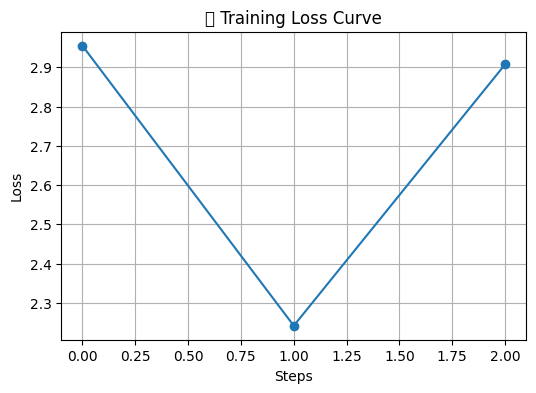

In [13]:
history = trainer.state.log_history
loss_values = [x['loss'] for x in history if 'loss' in x]
steps = [i for i in range(len(loss_values))]

plt.figure(figsize=(6,4))
plt.plot(steps, loss_values, marker='o')
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("📉 Training Loss Curve")
plt.grid(True)
plt.show()

In [15]:
from tqdm import tqdm
from transformers import pipeline

pipe = pipeline("text-generation", model=model, tokenizer=tokenizer, max_new_tokens=5)

y_pred = []
for idx, row in enumerate(X_test.itertuples()):
    output = pipe(row.text, temperature=0.1)
    answer = output[0]["generated_text"].split("Sentiment:")[-1].strip()
    if "positive" in answer.lower():
        y_pred.append("Positive")
    elif "negative" in answer.lower():
        y_pred.append("Negative")
    else:
        y_pred.append("Unknown")

print("✅ Predictions ready:", y_pred[:5])


Device set to use cuda:0


✅ Predictions ready: ['Positive', 'Positive']


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


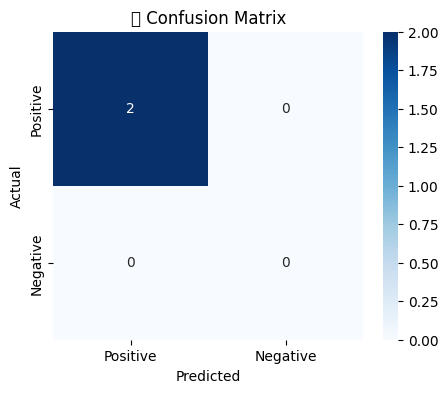

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=["Positive", "Negative"])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
            xticklabels=["Positive","Negative"],
            yticklabels=["Positive","Negative"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("📌 Confusion Matrix")
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


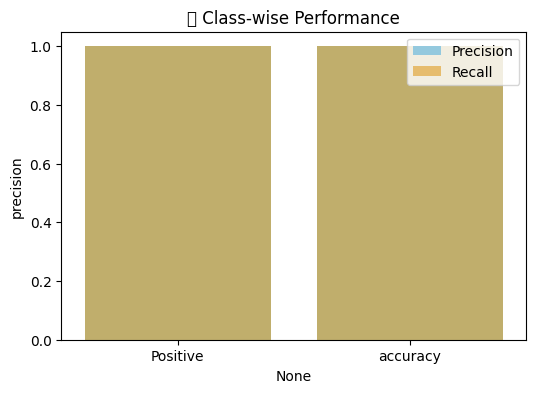

In [17]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(6,4))
sns.barplot(x=report_df.index[:2], y=report_df["precision"][:2], color="skyblue", label="Precision")
sns.barplot(x=report_df.index[:2], y=report_df["recall"][:2], color="orange", alpha=0.6, label="Recall")
plt.title("📊 Class-wise Performance")
plt.legend()
plt.show()